In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

import category_encoders as ce

import warnings
warnings.filterwarnings('ignore')


In [2]:

df = pd.read_csv('train.csv')

print(df.shape)
df.head()

(74111, 29)


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


In [3]:
y = df['log_price']



In [4]:
# Amenities count
df['amenities_count'] = df['amenities'].apply(lambda x: len(str(x).split(',')))

# Convert host_response_rate
# Ensure it's string before replacing '%'
df['host_response_rate'] = df['host_response_rate'].astype(str).str.replace('%','')
df['host_response_rate'] = pd.to_numeric(df['host_response_rate'], errors='coerce')

# List of columns to convert to date and then extract year
date_feature_cols = ['first_review','last_review','host_since']

for col in date_feature_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    df[col] = df[col].dt.year

# Define all columns that should be dropped completely (not transformed into a numerical feature in place)
cols_to_be_dropped_completely = [
    'id',                    # unique identifier
    'name',                  # high-cardinality text
    'description',           # noisy text
    'zipcode',               # too many unique values
    'host_name',             # many unique values
    'neighbourhood',         # often high cardinality
    'neighbourhood_cleansed',# similar issue (if it exists)
    'amenities'              # original amenities string column
]

# Drop the specified columns
df.drop(columns=cols_to_be_dropped_completely, inplace=True, errors='ignore')
more_drop_cols = [
    'latitude',
    'longitude',
    'availability_365',
    'number_of_reviews',
    'review_scores_rating'
]
df.drop(columns=more_drop_cols, inplace=True, errors='ignore')



In [5]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

In [6]:
X = df.drop('log_price', axis=1)
y = df['log_price']

In [7]:
cat_cols = X.select_dtypes(include='object').columns

encoder = ce.TargetEncoder(cols=cat_cols)

X = encoder.fit_transform(X, y)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
noise = np.random.normal(0, 0.2, size=y_train.shape[0])
y_train = y_train + noise

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Linear Regression R2 Score:", r2_score(y_test, pred_lr))

Linear Regression R2 Score: 0.7113870186017799


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score

# Parameter Grid
lr_params = {
    "fit_intercept": [True, False],
    "positive": [True, False]
}

lr = LinearRegression()

lr_cv = RandomizedSearchCV(
    lr,
    lr_params,
    n_iter=4,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

lr_cv.fit(X_train, y_train)

best_lr = lr_cv.best_estimator_

# Predictions
train_pred = best_lr.predict(X_train)
test_pred = best_lr.predict(X_test)

print("Best Parameters:", lr_cv.best_params_)
print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))

Best Parameters: {'positive': False, 'fit_intercept': True}
Train R2: 0.6521082821241231
Test R2: 0.7113870186017799


In [13]:
knn = KNeighborsRegressor(
    n_neighbors=5,
    weights='distance'
)

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

print("KNN R2 Score:", r2_score(y_test, pred_knn))

KNN R2 Score: 0.7605938628888234


In [14]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import RandomizedSearchCV

knn_params = {
    "n_neighbors": [3,5,7,9,11],
    "weights": ["uniform","distance"],
    "p": [1,2],
    "leaf_size": [20,30,40]
}

knn = KNeighborsRegressor()

knn_cv = RandomizedSearchCV(
    knn,
    knn_params,
    n_iter=10,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

knn_cv.fit(X_train, y_train)

best_knn = knn_cv.best_estimator_

# Predictions
train_pred = best_knn.predict(X_train)
test_pred = best_knn.predict(X_test)

print("Best Parameters:", knn_cv.best_params_)
print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))

Best Parameters: {'weights': 'distance', 'p': 1, 'n_neighbors': 11, 'leaf_size': 40}
Train R2: 0.9995085725436016
Test R2: 0.7845446117939562


In [15]:
dt = DecisionTreeRegressor(
    max_depth=20,
    min_samples_split=5,
    random_state=42
)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree R2 Score:", r2_score(y_test, pred_dt))

Decision Tree R2 Score: 0.8737278393826797


In [16]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest R2 Score :", r2_score(y_test, pred_rf))

Random Forest R2 Score : 0.9413256759440513


In [17]:
xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

print("XGBoost R2:", r2_score(y_test, pred_xgb))

XGBoost R2: 0.9413791662022172


In [18]:
gb = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)

print("Gradient Boosting R2:", r2_score(y_test, pred_gb))

Gradient Boosting R2: 0.946233340614157



=== Final Model Comparison ===
            Model  R² Score  CV Score     RMSE      MAE      Tuned
Gradient Boosting  0.946233       NaN 0.166197 0.055699          —
          XGBoost  0.941379       NaN 0.173537 0.068412          —
    Random Forest  0.941326       NaN 0.173616 0.072626          —
    Decision Tree  0.873728       NaN 0.254694 0.144567          —
              KNN  0.760594  0.725526 0.350698 0.244819 CV Applied
Linear Regression  0.711387  0.651669 0.385056 0.273740 CV Applied


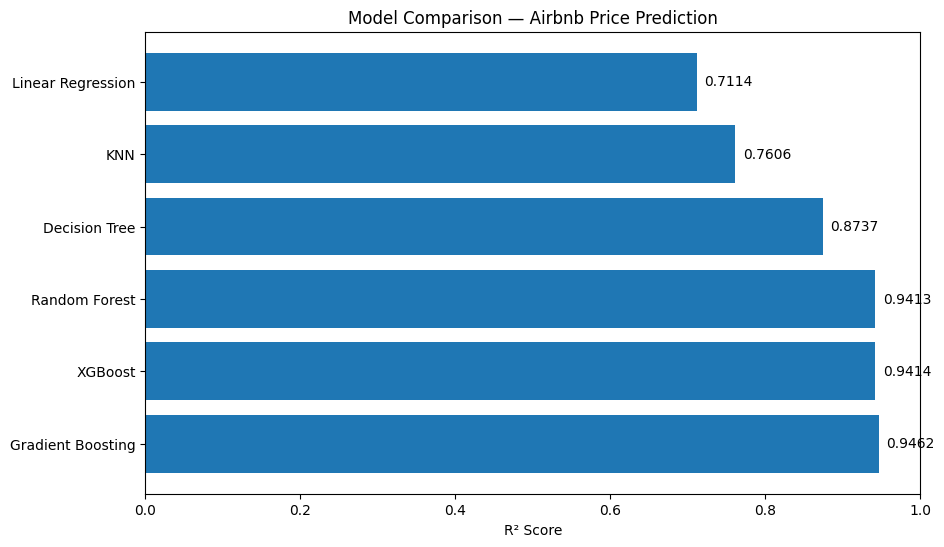

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

comparison_data = []

# Cross Validation Setup (Lightweight + Stable)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Linear Regression
cv_lr = cross_val_score(best_lr, X_train, y_train, cv=cv, scoring='r2').mean()

comparison_data.append({
    'Model': 'Linear Regression',
    'R² Score': r2_score(y_test, pred_lr),
    'CV Score': cv_lr,
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_lr)),
    'MAE': mean_absolute_error(y_test, pred_lr),
    'Tuned': 'CV Applied'
})

# KNN
cv_knn = cross_val_score(best_knn, X_train, y_train, cv=cv, scoring='r2').mean()

comparison_data.append({
    'Model': 'KNN',
    'R² Score': r2_score(y_test, pred_knn),
    'CV Score': cv_knn,
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_knn)),
    'MAE': mean_absolute_error(y_test, pred_knn),
    'Tuned': 'CV Applied'
})

# Decision Tree
comparison_data.append({
    'Model': 'Decision Tree',
    'R² Score': r2_score(y_test, pred_dt),
    'CV Score': np.nan,
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_dt)),
    'MAE': mean_absolute_error(y_test, pred_dt),
    'Tuned': '—'
})

# Random Forest
comparison_data.append({
    'Model': 'Random Forest',
    'R² Score': r2_score(y_test, pred_rf),
    'CV Score': np.nan,
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_rf)),
    'MAE': mean_absolute_error(y_test, pred_rf),
    'Tuned': '—'
})

# Gradient Boosting
comparison_data.append({
    'Model': 'Gradient Boosting',
    'R² Score': r2_score(y_test, pred_gb),
    'CV Score': np.nan,
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_gb)),
    'MAE': mean_absolute_error(y_test, pred_gb),
    'Tuned': '—'
})

# XGBoost
comparison_data.append({
    'Model': 'XGBoost',
    'R² Score': r2_score(y_test, pred_xgb),
    'CV Score': np.nan,
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_xgb)),
    'MAE': mean_absolute_error(y_test, pred_xgb),
    'Tuned': '—'
})

results_df = pd.DataFrame(comparison_data)\
    .sort_values('R² Score', ascending=False)\
    .reset_index(drop=True)

print('\n=== Final Model Comparison ===')
print(results_df.to_string(index=False))


# Plot Comparison
fig, ax = plt.subplots(figsize=(10,6))

bars = ax.barh(
    results_df['Model'],
    results_df['R² Score']
)

ax.set_xlabel('R² Score')
ax.set_title('Model Comparison — Airbnb Price Prediction')
ax.set_xlim(0, 1.0)

for bar, val in zip(bars, results_df['R² Score']):
    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{val:.4f}',
        va='center'
    )

plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

models = {
    "Linear Regression": best_lr,
    "KNN": best_knn,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "XGBoost": xgb
}

results = []

for name, model in models.items():
    
    # Train Predictions
    train_pred = model.predict(X_train)
    
    # Test Predictions
    test_pred = model.predict(X_test)
    
    # Scores
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    
    rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    mae = mean_absolute_error(y_test, test_pred)
    
    gap = abs(train_r2 - test_r2)
    
    results.append({
        "Model": name,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Gap": gap,
        "RMSE": rmse,
        "MAE": mae
    })

results_df = pd.DataFrame(results)

# Sort by best test score and lowest gap
results_df = results_df.sort_values(
    ["Test R2", "Gap"],
    ascending=[False, True]
).reset_index(drop=True)

print("\n===== Model Comparison =====\n")
print(results_df)


# Select Best Model (Avoid Overfitting)
# First try to find models with low overfitting (Gap < 0.05)
low_overfit_models = results_df[(results_df["Gap"] < 0.05)]

if len(low_overfit_models) > 0:
    best_model_row = low_overfit_models.iloc[0]
else:
    # If no model has Gap < 0.05, just select the best test R2
    best_model_row = results_df.iloc[0]

best_model_name = best_model_row["Model"]
best_model = models[best_model_name]
final_r2_score = best_model_row["Test R2"]

# Store feature names and model score for later use
feature_names = X.columns.tolist()
model_r2_score = final_r2_score

print("\n🏆 Best Model Selected:", best_model_name)
print("Test R2:", best_model_row["Test R2"])
print("Train-Test Gap:", best_model_row["Gap"])


===== Model Comparison =====

               Model  Train R2   Test R2       Gap      RMSE       MAE
0  Gradient Boosting  0.892751  0.946233  0.053482  0.166197  0.055699
1            XGBoost  0.910140  0.941379  0.031239  0.173537  0.068412
2      Random Forest  0.948922  0.941326  0.007597  0.173616  0.072626
3      Decision Tree  0.947266  0.873728  0.073539  0.254694  0.144567
4                KNN  0.999509  0.784545  0.214964  0.332694  0.226902
5  Linear Regression  0.652108  0.711387  0.059279  0.385056  0.273740

🏆 Best Model Selected: XGBoost
Test R2: 0.9413791662022172
Train-Test Gap: 0.031239181103119407


In [30]:
import os
os.makedirs('backend/models', exist_ok=True)
import pickle

pickle.dump(best_model, open('backend/models/best_airbnb_model.pkl', 'wb'))
pickle.dump(scaler, open('backend/models/scaler.pkl', 'wb'))
pickle.dump(feature_names, open('backend/models/features.pkl', 'wb'))
pickle.dump(encoder, open('backend/models/encoder.pkl', 'wb'))
pickle.dump(final_r2_score, open('backend/models/model_r2_score.pkl', 'wb'))

print("Model and artifacts saved successfully!")

Model and artifacts saved successfully!


In [31]:
def predict_airbnb_price(input_dict):

    # Convert to dataframe
    input_df = pd.DataFrame([input_dict])

    # Ensure all columns exist
    for col in feature_names:
        if col not in input_df:
            input_df[col] = 0

    # Reorder columns
    input_df = input_df[feature_names]

    # Encoding
    input_df = encoder.transform(input_df)

    # Scaling
    input_df = scaler.transform(input_df)

    # Prediction
    log_price = best_model.predict(input_df)[0]

    # Convert back from log
    price = np.expm1(log_price)

    # Return price + model confidence
    return {
        "Predicted Price (₹)": round(price, 2),
        "Model R2 Score": round(model_r2_score, 4)
    }